# AML-Lensed Credit Card Fraud Analysis

**Author:** Yağız Ege Demirel
**Date:** May 2026
**Dataset:** Kaggle Credit Card Fraud Detection (Université Libre de Bruxelles)

---

## What This Is

This notebook applies an Anti-Money Laundering investigative framework to the Kaggle Credit Card Fraud dataset. The goal is not to build a state-of-the-art classifier. It is to demonstrate how a transaction monitoring analyst reads transaction data: looking for behavioral anomalies, connecting statistical patterns to documented typologies, and translating model output into operational decisions.

The technical work is a vehicle for the framing. Not the other way around.

## What This Is Not

- A Kaggle competition entry optimized for leaderboard performance
- A benchmark of fraud detection approaches
- A production-ready model
- Evidence of money laundering (fraud and money laundering are distinct offences; this distinction matters and gets its own section)

## Why This Dataset

The dataset covers 284,807 transactions over two days, with 492 confirmed fraudulent transactions (0.173%). That extreme imbalance mirrors the real challenge of transaction monitoring: compliance teams are searching for fewer than 2 fraudulent transactions in every 1,000. That is not a data science problem. It is an operational one.

## Background

I am a final-year Law student at Kırıkkale University (graduating June 2026), concurrently studying Economics at Anadolu University. I hold Basel Institute on Governance certifications in Operational Analysis of Suspicious Transaction Reports and International Cooperation in Financial Matters, and an ACAMS certification in Wildlife Trade Finance.

I previously conducted an independent OSINT investigation on Troika Securities Limited (a BVI-registered shell entity from the ICIJ Panama Papers) using Basel STR format. That work is on a different vector (entity structure vs. transaction anomaly), but it informs the framing here: financial crime analysis is pattern recognition under uncertainty, not just modeling.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')
import os

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Visual style: restrained, single-accent palette
sns.set_theme(style="whitegrid", context="notebook")
FRAUD_COLOR = "#C0392B"
LEGIT_COLOR = "#2E86AB"

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

VIZ_DIR = "../visualizations"
os.makedirs(VIZ_DIR, exist_ok=True)

print("Setup complete.")


Setup complete.


In [2]:
df = pd.read_csv('../data/creditcard.csv')

print(f"Total transactions : {df.shape[0]:,}")
print(f"Features           : {df.shape[1]}")
print(f"Fraudulent cases   : {df['Class'].sum():,}")
print(f"Fraud rate         : {df['Class'].mean() * 100:.3f}%")
print(f"Time span          : {df['Time'].max() / 3600:.1f} hours")
print()
df.describe()[['Time', 'Amount', 'Class']].round(2)


Total transactions : 284,807
Features           : 31
Fraudulent cases   : 492
Fraud rate         : 0.173%
Time span          : 48.0 hours



,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00


## Section 1: Dataset Overview

### The Data

This dataset contains European credit card transactions from September 2013: two days, 284,807 rows, 492 fraud cases.

Features V1 through V28 are the result of PCA transformation applied by the original researchers. The original feature names are not disclosed. Only `Time`, `Amount`, and `Class` retain their original meaning. `Time` is seconds elapsed since the first transaction in the dataset. `Amount` is the transaction value in EUR.

### Class Imbalance as Operational Context

0.173% fraud rate. In a transaction monitoring context, this is not unusual. The challenge is not identifying fraud in isolation; it is doing so at scale, where every false positive represents time an analyst spends reviewing a legitimate transaction instead of an actual suspicious one.

A system processing 10 million daily transactions with a 1% false positive rate generates 100,000 alert reviews per day. At 15 minutes per review, that is 25,000 analyst-hours. Per day. The precision-recall tradeoff in fraud detection is a resource allocation decision before it is a technical one.


### Data Governance Note

The V1-V28 features were anonymized via PCA prior to publication. This is worth noting not just as a technical limitation, but as a data protection control.

Under **GDPR Article 5(1)(c)** (data minimisation), personal data processed for a given purpose should be "adequate, relevant and limited to what is necessary." When financial transaction data crosses jurisdictional lines, as it does in FIU-to-FIU information sharing under the **Egmont Group** framework, pseudonymisation and feature masking are standard controls applied before data is transferred or published.

Working with anonymized features is therefore not a reduced version of financial crime analysis. It is a common structural constraint. Analysts in cross-border investigations routinely work with data that has been partially obfuscated by the originating institution. The skill is reading what the transformed data still shows.

The PCA transformation destroys interpretability of individual features but preserves the statistical relationships between them. Anomaly patterns remain detectable even without knowing what V1 or V7 originally represented.


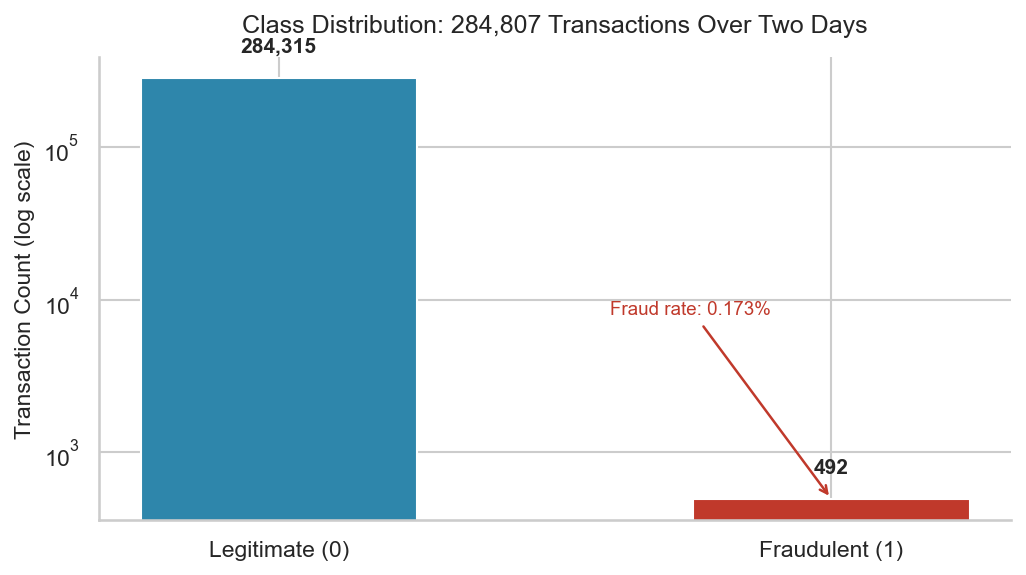

Saved: 01_class_distribution.png


In [3]:
class_counts = df['Class'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['Legitimate (0)', 'Fraudulent (1)'],
    class_counts.values,
    color=[LEGIT_COLOR, FRAUD_COLOR],
    width=0.5, edgecolor='white'
)
ax.set_yscale('log')
ax.set_ylabel('Transaction Count (log scale)', fontsize=11)
ax.set_title('Class Distribution: 284,807 Transactions Over Two Days', fontsize=12, pad=12)

for bar, count in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.4,
        f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.annotate(
    'Fraud rate: 0.173%',
    xy=(1, class_counts[1]), xytext=(0.6, 8000),
    fontsize=9, color=FRAUD_COLOR,
    arrowprops=dict(arrowstyle='->', color=FRAUD_COLOR, lw=1.2)
)

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/01_class_distribution.png", bbox_inches='tight')
plt.show()
print("Saved: 01_class_distribution.png")


## Section 2: Exploratory Data Analysis

### Transaction Amounts

`Amount` is one of only two features in this dataset that is not anonymized. The distribution tells a clear story.

Legitimate transactions follow a right-skewed distribution typical of retail spending: most are small, with a long tail of larger purchases. Median: 22.00 EUR.

Fraudulent transactions cluster sharply at the low end: median 9.25 EUR, maximum 2,125.87 EUR versus 25,691.16 EUR for legitimate. The average fraudulent transaction (122.21 EUR) is higher than the median (9.25 EUR) because of a few high-value outliers, but the dominant pattern is small-amount clustering.

This is consistent with a documented typology: **credential testing** (sometimes called card verification). Fraudsters who acquire stolen card data typically test credentials with a micro-transaction before attempting larger purchases. The low-value cluster in the fraud distribution is consistent with this behavior. FATF's typology work on payment card fraud documents this pattern in card-not-present contexts.

The implication for a rule designer: transactions under 5 EUR with elevated model scores are a natural candidate for a targeted alert rule. More on this in Section 6.


Legitimate  |  Median: 22.00  |  Mean: 88.29  |  Max: 25691.16
Fraudulent  |  Median: 9.25   |  Mean: 122.21  |  Max: 2125.87


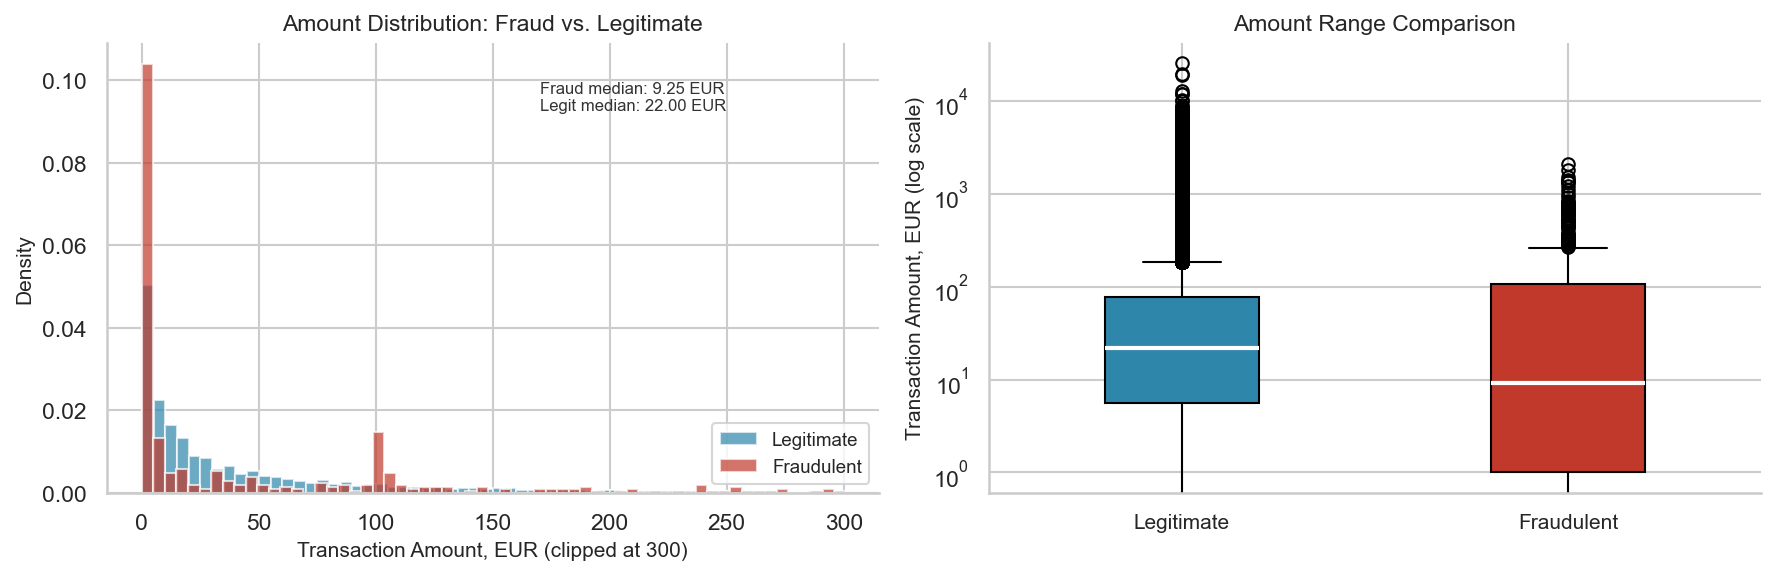

Saved: 02_amount_by_class.png


In [4]:
legit = df[df['Class'] == 0]['Amount']
fraud = df[df['Class'] == 1]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: overlapping histograms, clipped at 300 EUR for readability
axes[0].hist(legit[legit <= 300], bins=60, color=LEGIT_COLOR, alpha=0.7,
             label='Legitimate', density=True)
axes[0].hist(fraud[fraud <= 300], bins=60, color=FRAUD_COLOR, alpha=0.7,
             label='Fraudulent', density=True)
axes[0].set_xlabel('Transaction Amount, EUR (clipped at 300)', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].set_title('Amount Distribution: Fraud vs. Legitimate', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].text(170, axes[0].get_ylim()[1] * 0.85,
             f'Fraud median: 9.25 EUR\nLegit median: 22.00 EUR',
             fontsize=8, color='#333')

# Right: box plots on log scale
bp = axes[1].boxplot([legit, fraud], patch_artist=True, widths=0.4,
                     medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(LEGIT_COLOR)
bp['boxes'][1].set_facecolor(FRAUD_COLOR)
axes[1].set_yscale('log')
axes[1].set_xticklabels(['Legitimate', 'Fraudulent'], fontsize=10)
axes[1].set_ylabel('Transaction Amount, EUR (log scale)', fontsize=10)
axes[1].set_title('Amount Range Comparison', fontsize=11)

print(f"Legitimate  |  Median: {legit.median():.2f}  |  Mean: {legit.mean():.2f}  |  Max: {legit.max():.2f}")
print(f"Fraudulent  |  Median: {fraud.median():.2f}   |  Mean: {fraud.mean():.2f}  |  Max: {fraud.max():.2f}")

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/02_amount_by_class.png", bbox_inches='tight')
plt.show()
print("Saved: 02_amount_by_class.png")


### Temporal Patterns

**Important caveat on the time assumption:** The `Time` feature records seconds elapsed since the first transaction in the dataset. Actual wall-clock time is not provided by the dataset. Following common convention, I assume the first transaction occurs at midnight (00:00). This assumption is unverified. Any hour-of-day analysis should be read with that caveat in mind.

With that stated: examining fraud rate by hour of day is still analytically useful. The relative pattern, when fraud spikes relative to normal transaction volume, holds regardless of the absolute time assumption.


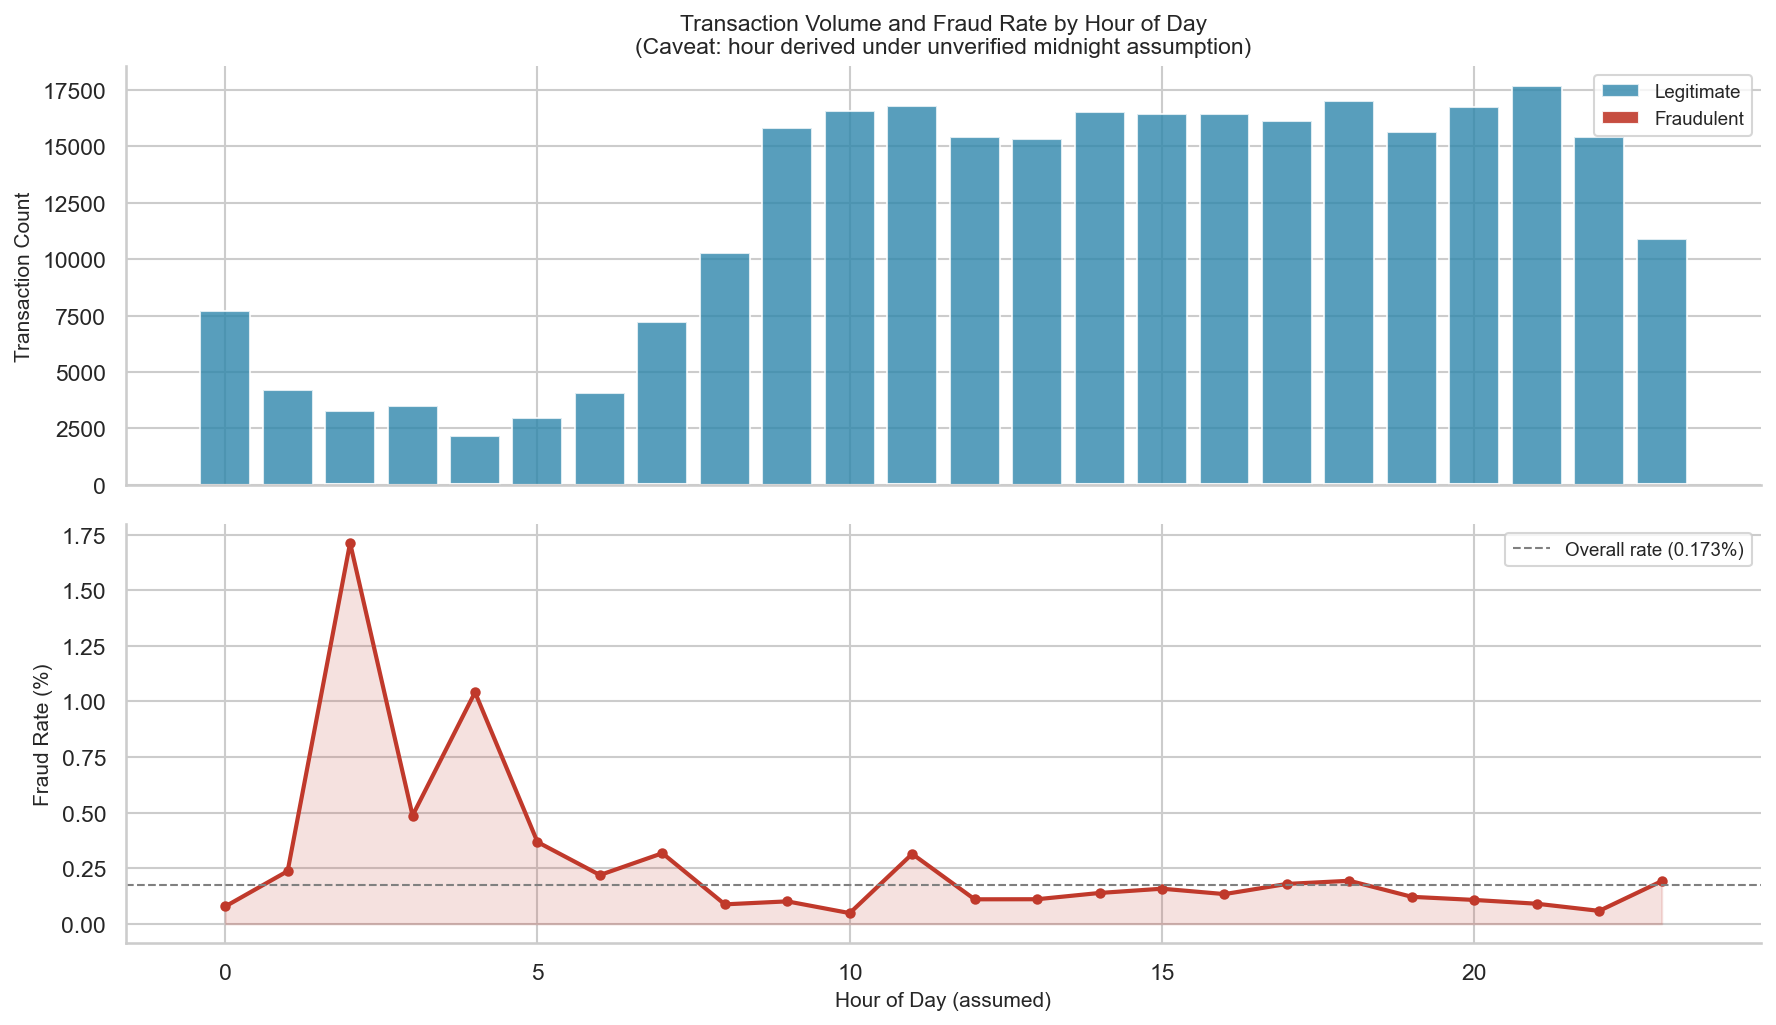

Top 3 hours by fraud rate:
      fraud_count  total_count  fraud_rate
Hour                                      
2              57         3328      0.0171
4              23         2209      0.0104
3              17         3492      0.0049

Saved: 03_temporal_pattern.png


In [5]:
df_temp = df.copy()
df_temp['Hour'] = (df_temp['Time'] // 3600).astype(int) % 24

hourly = df_temp.groupby('Hour')['Class'].agg(['sum', 'count'])
hourly.columns = ['fraud_count', 'total_count']
hourly['fraud_rate'] = hourly['fraud_count'] / hourly['total_count']
hourly['legit_count'] = hourly['total_count'] - hourly['fraud_count']

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(hourly.index, hourly['legit_count'], color=LEGIT_COLOR,
            label='Legitimate', alpha=0.8)
axes[0].bar(hourly.index, hourly['fraud_count'], color=FRAUD_COLOR,
            label='Fraudulent', alpha=0.9)
axes[0].set_ylabel('Transaction Count', fontsize=10)
axes[0].set_title(
    'Transaction Volume and Fraud Rate by Hour of Day\n'
    '(Caveat: hour derived under unverified midnight assumption)',
    fontsize=11
)
axes[0].legend(fontsize=9)

axes[1].plot(hourly.index, hourly['fraud_rate'] * 100,
             color=FRAUD_COLOR, linewidth=2, marker='o', markersize=4)
axes[1].fill_between(hourly.index, hourly['fraud_rate'] * 100,
                     alpha=0.15, color=FRAUD_COLOR)
axes[1].axhline(df['Class'].mean() * 100, color='grey', linestyle='--',
                linewidth=1, label=f"Overall rate (0.173%)")
axes[1].set_xlabel('Hour of Day (assumed)', fontsize=10)
axes[1].set_ylabel('Fraud Rate (%)', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/03_temporal_pattern.png", bbox_inches='tight')
plt.show()

print("Top 3 hours by fraud rate:")
print(hourly.nlargest(3, 'fraud_rate')[['fraud_count', 'total_count', 'fraud_rate']].round(4))
print("\nSaved: 03_temporal_pattern.png")


### What the EDA Shows

Three observations that matter from an AML perspective:

**1. Low-value fraud clustering**
Median fraudulent amount is 9.25 EUR versus 22.00 EUR for legitimate. This is consistent with credential-testing behavior: fraudsters acquiring stolen card data from carding markets typically verify the card with a micro-transaction before escalating. FATF's 2020 guidance on virtual asset fraud documents this pattern in card-not-present contexts.

**2. Off-hours fraud concentration** (with the midnight-assumption caveat)
Fraud rate peaks at hours 2, 4, and 3 under the midnight assumption: 1.71%, 1.04%, and 0.49% respectively, versus an overall rate of 0.173%. Hours 2 and 4 show fraud rates roughly 6-10x the baseline. Automated testing scripts tend to run at low-activity hours where velocity anomalies are harder to detect and human oversight is reduced.

**3. The imbalance is the job**
492 confirmed fraud cases in 284,807 transactions. A transaction monitoring analyst reviewing a random alert has roughly a 0.17% prior probability the transaction is genuinely fraudulent. Most alerts are false positives by design. This is why precision is not just a technical metric here; it is a staffing constraint.


## Section 3: Detection Model

### Why Logistic Regression

The choice of model in a transaction monitoring system is a regulatory decision, not just a performance one.

**GDPR Article 22** gives individuals the right not to be subject to decisions based solely on automated processing that produce legal or similarly significant effects. Freezing a customer's credit card qualifies. The Article 22 safeguards include the right to obtain human review and an explanation of the decision.

A model whose internal weights cannot be extracted and expressed in plain language cannot provide that explanation. A neural network that outputs a fraud probability of 0.87 cannot tell an analyst, or a customer, which aspects of the transaction drove that score.

Logistic Regression can. Each feature coefficient has a sign and a magnitude: it tells you whether that feature pushed the probability toward fraud or toward legitimate, and by how much. In an alert narrative, this translates to: "This transaction was flagged primarily because the scaled amount (coefficient: +2.1) and feature V14 (coefficient: -3.4) jointly exceeded the alert threshold."

That is a defensible narrative. A black box is not.

The argument for Logistic Regression in this context is not accuracy. It is explainability as a compliance requirement.

### Handling Class Imbalance

With 0.173% fraud in the full dataset, a naive model that predicts "legitimate" for every transaction achieves 99.83% accuracy while being completely useless. To train a model that can distinguish fraud from legitimate, the class imbalance needs to be addressed.

Two common approaches: over-sampling (synthetic minority class generation, e.g., SMOTE) or under-sampling (reducing the majority class). For this PoC, I use **random under-sampling**: 492 legitimate transactions selected at random to match the 492 fraud cases, creating a balanced training pool of 984 transactions.

This comes at a cost. 283,823 legitimate transactions are excluded from training. The model learns from a sample, not the population. Precision and recall on the balanced test set will look better than performance on the full imbalanced dataset. This distinction matters. Both evaluations are included below.


In [6]:
# Preserve full dataset before undersampling for later evaluation
df_full = df.copy()

# RobustScaler is resistant to outliers in Amount, suitable for transaction data
scaler = RobustScaler()
df_full['scaled_amount'] = scaler.fit_transform(df_full['Amount'].values.reshape(-1, 1))
df_full['scaled_time']   = scaler.fit_transform(df_full['Time'].values.reshape(-1, 1))
df_full.drop(['Time', 'Amount'], axis=1, inplace=True)

sa = df_full.pop('scaled_amount')
st = df_full.pop('scaled_time')
df_full.insert(0, 'scaled_amount', sa)
df_full.insert(1, 'scaled_time', st)

print(f"Scaled dataset: {df_full.shape[0]:,} rows, {df_full.shape[1]} columns")
print(f"Features for modeling: {list(df_full.columns[:-1])[:5]}... (30 total)")


Scaled dataset: 284,807 rows, 31 columns
Features for modeling: ['scaled_amount', 'scaled_time', 'V1', 'V2', 'V3']... (30 total)


In [7]:
df_shuffled = df_full.sample(frac=1, random_state=RANDOM_SEED)

fraud_df     = df_shuffled[df_shuffled['Class'] == 1]
non_fraud_df = df_shuffled[df_shuffled['Class'] == 0][:492]

balanced_df = pd.concat([fraud_df, non_fraud_df])
balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_SEED)

print(f"Balanced training pool: {len(balanced_df)} transactions")
print(balanced_df['Class'].value_counts().to_string())
print(f"\n{len(df_full) - len(balanced_df):,} legitimate transactions excluded from training.")


Balanced training pool: 984 transactions
Class
0    492
1    492

283,823 legitimate transactions excluded from training.


In [8]:
X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model.fit(X_train, y_train)

print(f"Training set : {len(X_train)} rows  ({y_train.sum()} fraud, {(y_train==0).sum()} legitimate)")
print(f"Test set     : {len(X_test)} rows  ({y_test.sum()} fraud, {(y_test==0).sum()} legitimate)")
print("\nModel trained.")


Training set : 787 rows  (394 fraud, 393 legitimate)
Test set     : 197 rows  (98 fraud, 99 legitimate)

Model trained.


## Section 4: Evaluation

### Reading the Metrics

Accuracy is not the metric here. The relevant ones are precision and recall on the fraud class.

**Precision (Fraud):** Of the transactions the model flags as fraud, what fraction actually are? High precision means fewer false positives, less wasted analyst time.

**Recall (Fraud):** Of all actual fraud cases, what fraction does the model catch? High recall means fewer missed cases, less operational risk from undetected fraud.

These trade off against each other. Lowering the decision threshold increases recall (catch more fraud) but degrades precision (generate more false positives). The right setting depends on the institution's risk appetite and analyst capacity. Two named configurations are evaluated below, after the baseline results.

Two evaluations follow: first on the balanced test set (shows how the model performs on evenly distributed classes), then on the full 284,807-transaction dataset (shows what this would look like in production).


=== Evaluation on Balanced Test Set (197 transactions, 50/50 split) ===
Note: this overstates real-world performance; see full-dataset evaluation below.

              precision    recall  f1-score   support

  Legitimate       0.90      0.97      0.93        99
  Fraudulent       0.97      0.89      0.93        98

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197



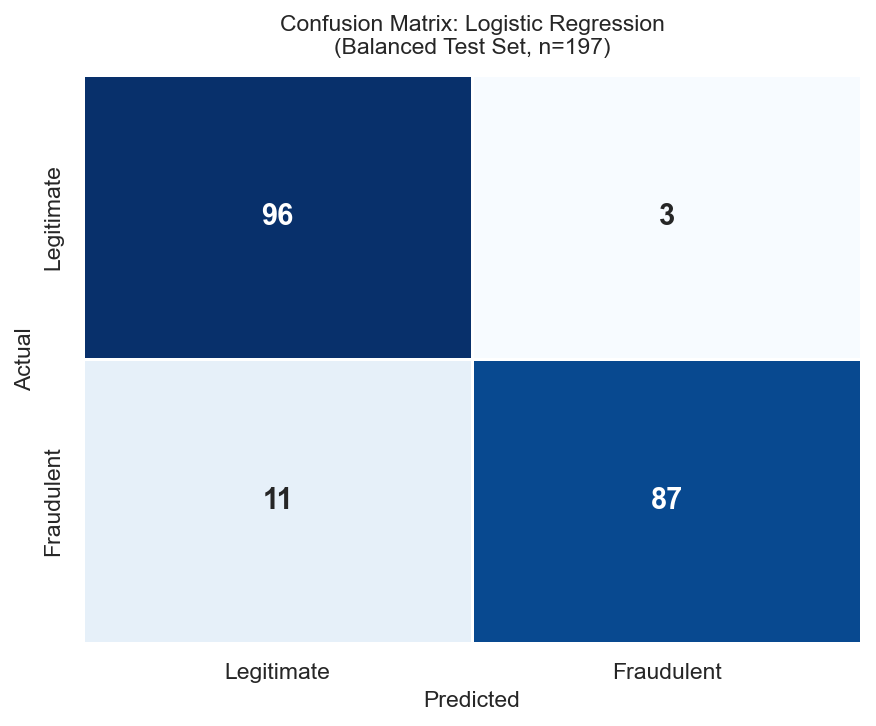

Saved: 04_confusion_matrix.png


In [9]:
preds_balanced = model.predict(X_test)

print("=== Evaluation on Balanced Test Set (197 transactions, 50/50 split) ===")
print("Note: this overstates real-world performance; see full-dataset evaluation below.\n")
print(classification_report(y_test, preds_balanced,
                            target_names=['Legitimate', 'Fraudulent']))

cm = confusion_matrix(y_test, preds_balanced)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Legitimate', 'Fraudulent'],
    yticklabels=['Legitimate', 'Fraudulent'],
    linewidths=0.5, linecolor='white',
    annot_kws={"size": 14, "weight": "bold"},
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Confusion Matrix: Logistic Regression\n(Balanced Test Set, n=197)', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/04_confusion_matrix.png", bbox_inches='tight')
plt.show()
print("Saved: 04_confusion_matrix.png")


In [10]:
X_full = df_full.drop('Class', axis=1)
y_full = df_full['Class']

probs_full = model.predict_proba(X_full)[:, 1]
preds_full = model.predict(X_full)

tn, fp, fn, tp = confusion_matrix(y_full, preds_full).ravel()

print("=== Evaluation on Full Dataset (284,807 transactions, real-world imbalance) ===\n")
print(f"  True Positives   (fraud correctly flagged)    : {tp:>6}")
print(f"  False Positives  (legitimate wrongly flagged) : {fp:>6,}")
print(f"  True Negatives   (legitimate correctly cleared): {tn:>6,}")
print(f"  False Negatives  (fraud missed)               : {fn:>6}")
print()
print(f"  Fraud recall on full dataset : {tp/(tp+fn):.3f}  ({tp} of {tp+fn} fraud cases caught)")
print(f"  Precision on full dataset    : {tp/(tp+fp):.3f}  ({tp} true positives per {tp+fp:,} alerts generated)")
print(f"  False positive rate          : {fp/(fp+tn)*100:.2f}% of legitimate transactions flagged")


=== Evaluation on Full Dataset (284,807 transactions, real-world imbalance) ===

  True Positives   (fraud correctly flagged)    :    456
  False Positives  (legitimate wrongly flagged) : 10,035
  True Negatives   (legitimate correctly cleared): 274,280
  False Negatives  (fraud missed)               :     36

  Fraud recall on full dataset : 0.927  (456 of 492 fraud cases caught)
  Precision on full dataset    : 0.043  (456 true positives per 10,491 alerts generated)
  False positive rate          : 3.53% of legitimate transactions flagged


In [11]:
def eval_threshold(probs, y_true, threshold, name):
    p = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, p).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    ah   = fp * 15 / 60
    print(f"\n{'='*55}")
    print(f"  {name}  (threshold = {threshold})")
    print(f"{'='*55}")
    print(f"  TP={tp}  FP={fp:,}  TN={tn:,}  FN={fn}")
    print(f"  Precision : {prec:.3f}    Recall : {rec:.3f}    F1 : {f1:.3f}")
    print(f"  False positives generated over 48h : {fp:,}")
    print(f"  Analyst-hours consumed (FP x 15min): {ah:.0f} h  "
          f"({ah/2:.0f} h/day  |  {ah/8:.0f} FTE on an 8-hour shift)")
    return tp, fp, fn, tn, prec, rec

tp_a, fp_a, fn_a, tn_a, prec_a, rec_a = eval_threshold(
    probs_full, y_full, 0.30, "Configuration A: High-Recall, FATF-Aligned"
)
tp_b, fp_b, fn_b, tn_b, prec_b, rec_b = eval_threshold(
    probs_full, y_full, 0.70, "Configuration B: High-Precision, Cost-Constrained"
)



  Configuration A: High-Recall, FATF-Aligned  (threshold = 0.3)
  TP=469  FP=21,445  TN=262,870  FN=23
  Precision : 0.021    Recall : 0.953    F1 : 0.042
  False positives generated over 48h : 21,445
  Analyst-hours consumed (FP x 15min): 5361 h  (2681 h/day  |  670 FTE on an 8-hour shift)

  Configuration B: High-Precision, Cost-Constrained  (threshold = 0.7)
  TP=446  FP=5,479  TN=278,836  FN=46
  Precision : 0.075    Recall : 0.907    F1 : 0.139
  False positives generated over 48h : 5,479
  Analyst-hours consumed (FP x 15min): 1370 h  (685 h/day  |  171 FTE on an 8-hour shift)


### Reading the Two Configurations

**Configuration A: High-Recall, FATF-Aligned (threshold = 0.30)**

Every transaction with a fraud probability above 30% is flagged. This catches more fraud at the cost of substantially more false positives.

When would an institution choose this? When missing a fraudulent transaction carries a higher operational and regulatory cost than investigating false positives. Under **FATF Recommendation 20**, obligated entities must file STRs when they have reasonable grounds to suspect a transaction involves proceeds of crime. "Reasonable grounds" is a deliberately low bar. An institution under active supervisory scrutiny, or operating in a high-risk jurisdiction, would lean toward Configuration A. The cost of a missed case, whether measured in regulatory sanction or reputational exposure, outweighs the cost of excess alerts.

**Configuration B: High-Precision, Cost-Constrained (threshold = 0.70)**

Only transactions with a fraud probability above 70% are flagged. This reduces alert volume at the cost of missing more fraud.

When would an institution choose this? When L1 analyst capacity is the binding constraint. A regional bank or smaller fintech with limited compliance headcount cannot absorb thousands of daily reviews. Precision becomes the operational priority. The institution has effectively decided that the cost of missing lower-probability fraud is acceptable given the staffing constraint. This is a risk appetite decision that belongs to the institution's MLRO and senior management, not to the model.

Neither configuration is correct in the abstract. The right choice is a function of regulatory environment, customer risk profile, and operational capacity.


In [12]:
REVIEW_MINUTES = 15  # stated assumption: 15 minutes per L1 triage review
HOURS_IN_DATASET = 48  # dataset covers 2 days

print("=== Analyst Workload Simulation ===")
print(f"Assumption: {REVIEW_MINUTES} minutes per L1 alert review")
print(f"Dataset window: {HOURS_IN_DATASET} hours\n")

_, fp_default, _, _ = confusion_matrix(y_full, preds_full).ravel()

for label, fp_count in [
    ("Default threshold (0.50)", fp_default),
    ("Config A (0.30) - High-Recall", fp_a),
    ("Config B (0.70) - High-Precision", fp_b),
]:
    total_h = fp_count * REVIEW_MINUTES / 60
    per_day  = total_h / 2
    fte      = total_h / 8
    print(f"  {label}")
    print(f"    False positives over 48h : {fp_count:,}")
    print(f"    Total analyst-hours      : {total_h:,.0f} h")
    print(f"    Per day                  : {per_day:,.0f} h")
    print(f"    FTE equivalent (8h shift): {fte:,.0f}")
    print()

print("These numbers reflect the 284,807-transaction dataset window only.")
print("Scale proportionally to estimate annualized compliance department cost.")


=== Analyst Workload Simulation ===
Assumption: 15 minutes per L1 alert review
Dataset window: 48 hours

  Default threshold (0.50)
    False positives over 48h : 10,035
    Total analyst-hours      : 2,509 h
    Per day                  : 1,254 h
    FTE equivalent (8h shift): 314

  Config A (0.30) - High-Recall
    False positives over 48h : 21,445
    Total analyst-hours      : 5,361 h
    Per day                  : 2,681 h
    FTE equivalent (8h shift): 670

  Config B (0.70) - High-Precision
    False positives over 48h : 5,479
    Total analyst-hours      : 1,370 h
    Per day                  : 685 h
    FTE equivalent (8h shift): 171

These numbers reflect the 284,807-transaction dataset window only.
Scale proportionally to estimate annualized compliance department cost.


## Section 5: What This Does Not Show

This analysis detects statistical anomalies in transaction patterns. It does not detect money laundering.

The distinction matters. Fraud and money laundering are separate legal concepts with different elements, different reporting obligations, and different investigative standards. Card fraud, as captured in this dataset, typically involves unauthorized use of compromised credentials for direct financial gain. Money laundering, under most jurisdictions, requires that funds derive from criminal activity and that steps are taken to conceal that origin. These offences can overlap, but they are not the same.

Whether any transaction flagged by this model constitutes a reportable suspicion under **POCA 2002** (UK Proceeds of Crime Act, Section 330), **§261 StGB** (German money laundering provision), or the relevant national implementation of **EU AMLD6** is a question this model cannot answer. That determination requires human review of customer context, account history, source of funds, and the broader transaction narrative. A fraud probability of 0.87 is not "reasonable grounds to suspect." It is a starting point for investigation.

A transaction monitoring system that generates alerts is the beginning of an AML process, not the end.


## Section 6: AML Interpretation

### What a Transaction Monitoring Rule Designer Would Do With This

Model output is not an action. It is an input to a rule. In production TM systems, model scores are combined with deterministic rules, customer risk ratings, and alert history to generate investigative priorities. Based on the patterns observed in this analysis, here are three hypothetical rules a rule designer might draft.

---

**Rule 1: Micro-Transaction Credential Testing**

```
ALERT IF:
  Amount < 5.00 EUR
  AND model_fraud_score > 0.65
  AND channel = card-not-present
```

**Rationale:** Low-value transactions with elevated fraud scores are consistent with card credential testing. Fraudsters acquiring stolen card data typically execute a small verification transaction before escalating to higher-value purchases. This pattern is documented in FATF's *Guidance on Payment Card Fraud* (2015) and in card scheme operator typology publications. The 5 EUR threshold reflects the concentration of fraud in the sub-10 EUR range observed in this dataset (fraud median: 9.25 EUR).

---

**Rule 2: Off-Hours Automated Activity**

```
ALERT IF:
  transaction_hour IN (1, 2, 3, 4)    [midnight assumption]
  AND model_fraud_score > 0.70
  AND no prior transaction on this card in preceding 30 days
```

**Rationale:** Fraud rate in this dataset is 6-10x the baseline during hours 2-4 (under the midnight assumption). Automated fraud scripts often operate during low-activity hours where velocity anomalies are harder to detect. The dormant account condition (no prior 30-day activity) targets first-use credential testing, a common indicator in card-not-present fraud. Off-hours transaction clustering is widely documented in industry fraud operations literature (Visa Risk Insights, Mastercard Fraud Trends Reports) though no specific FATF typology report addresses this pattern as a discrete typology. The pattern reflects general fraud opportunism rather than a money laundering structuring technique.

---

**Rule 3: High-Score Catch-All**

```
ALERT IF:
  model_fraud_score > 0.85
  AND no other rule has triggered for this transaction
```

**Rationale:** A catch-all for high-probability model outputs that do not match a specific typology rule. The 0.85 threshold corresponds approximately to Configuration B precision territory, keeping false positives manageable for this discretionary alert category. This reflects standard TM practice of layering rules with model scoring rather than relying exclusively on either. No specific citation; standard TM architecture practice.

---

### Limits of These Rules

V1-V28 are anonymized. The rules above that reference `model_fraud_score` are workable. Rules referencing merchant category, geographic data, or transaction velocity over a customer account baseline cannot be written from this dataset. In a production environment, those features would exist and would significantly improve rule specificity.


## Section 7: Limitations and Next Steps

### What This Analysis Cannot Do

**1. The features are opaque.** V1-V28 are PCA-transformed. Any connection between individual features and a named typology (velocity, merchant category, geographic deviation) is speculative. The amount and time observations are grounded; the V-feature observations are not interpretable by name.

**2. No customer context.** A real transaction monitoring investigation includes: customer risk tier (FATF's risk-based approach requires this), account age, KYC documentation status, jurisdiction, and prior SAR history. A 0.87 fraud score on a high-risk customer with a dormant account in a high-risk jurisdiction means something different than the same score on a verified low-risk retail customer. This dataset provides none of that context.

**3. Model trained on a sub-sample.** Under-sampling excludes 283,823 legitimate transactions from training. The balanced test set results (precision 0.97, recall 0.89) overstate real-world performance. The full-dataset evaluation is more honest: recall 0.927, precision 0.043 at the default threshold. Most alerts on the full dataset are false positives. That is the real operating condition.

**4. Two days of data.** Transaction monitoring requires longitudinal analysis. A two-day window cannot capture seasonal behavior, evolving fraud patterns, or customer behavioral baselines. A model trained on this window would need regular retraining in production.

### What a Real Investigation Would Add

- **Per-customer aggregation.** Transaction velocity (multiple charges in seconds from the same card) is not visible in this row-level dataset. It is one of the most reliable fraud signals.
- **Merchant category codes.** A card normally used at supermarkets suddenly charging at electronics retailers is a detectable pattern. Not available here.
- **Geographic data.** Rapid successive transactions from geographically distant terminals ("impossible travel") is a high-confidence fraud indicator. Not available here.
- **SAR/STR history cross-reference.** Whether the cardholder or counterparty is already the subject of a prior suspicious activity report is material context. Not available here.

### For Future Iterations

The most valuable extension would not be a more complex model. It would be behavioral feature engineering: per-customer average transaction amount, velocity in the preceding 24 hours, merchant category distribution. Deviation from an established customer baseline is more informative than anomaly relative to the global population, and it is how most mature TM systems are actually built.
